
# K-Means Clustering — Derivation, Clarification, Matrix Form, and Elegant Implementation

This notebook is designed as a **Didactic reference**:

$$
\boxed{\text{rigorous mathematics} \;\longleftrightarrow\; \text{conceptual clarity} \;\longleftrightarrow\; \text{executable code}}
$$

It reconstructs K-Means from its objective function, integrates the clarification points that arose during the derivation discussion, derives the matrix centroid update, and implements Lloyd's algorithm in a compact **Norvig-style** form.

## Notebook goals

1. Define the optimization problem precisely.
2. Make the roles of $Z$ and $M$ explicit.
3. Explain why the assignment step contains an $\arg\min$.
4. Explain why a derivation for one $x_i$ actually applies independently to all $N$ observations.
5. Derive the centroid update without skipping the vector-calculus steps.
6. Derive the matrix update

$$
\boxed{
M =
\operatorname{diag}(Z^T\mathbf 1_N)^{-1} Z^T X
}
$$

7. Implement the algorithm so that the code reads almost like the mathematics.
8. Cluster synthetic points and visualize the result.


**The central idea of K-Means is unusually clean**:

$$ \boxed{ \text{Represent }N\text{ observations using }K\text{ prototype vectors while minimizing squared reconstruction error.} } $$

Everything in the algorithm follows from that single optimization problem.

K-Means is best understood not as "repeatedly move some dots around," but as alternating optimization over two coupled unknowns:

which centroid represents each observation;
where those centroids should be.

The classical K-Means criterion is the within-cluster sum of squared Euclidean distances. Pollard gives the equivalent population/statistical formulation and shows that cluster means arise necessarily from minimizing this criterion. Hartigan and Wong's classic algorithm is another foundational treatment of computational K-Means clustering.**bold text**


## 1. Setup and notation

We use the **row-observation convention**:

$$
X =
\begin{bmatrix}
x_1^T\\
x_2^T\\
\vdots\\
x_N^T
\end{bmatrix}
\in \mathbb{R}^{N\times D},
\qquad
x_i\in\mathbb{R}^{D}.
$$

Here:

- $N$: number of observations
- $D$: number of features
- $K$: number of clusters

A mathematical feature vector $x_i$ is treated as a column vector in $\mathbb R^D$, while $x_i^T$ is laid across row $i$ of the NumPy matrix $X$.

### Clarification checkpoint — row versus column convention

This distinction matters later.

Because observations are stored as **rows**,

$$
X:(N,D).
$$

Therefore

$$
Z^T X:
(K,N)(N,D)
=
(K,D)
$$

is valid and gives one row per cluster.

If instead observations were stored as columns,

$$
X_{\text{col}}\in\mathbb R^{D\times N},
$$

the corresponding cluster-sum operation would be $X_{\text{col}}Z$, not $Z^TX_{\text{col}}$.



## 2. The two unknowns: assignments and centroid locations

K-Means must infer **two coupled objects**.

### Assignment matrix

For each point $x_i$, define

$$
z_{ik}\in\{0,1\}
$$

with

$$
z_{ik}
=
\begin{cases}
1,&x_i\text{ is assigned to cluster }k,\\
0,&\text{otherwise}.
\end{cases}
$$

Collect the assignments into

$$
Z\in\{0,1\}^{N\times K}.
$$

Every row of $Z$ is one-hot:

$$
\boxed{
\sum_{k=1}^{K} z_{ik}=1
}
\qquad\forall i.
$$

### Centroid matrix

Each centroid is

$$
\mu_k\in\mathbb R^D.
$$

Collect the centroids as rows:

$$
M=
\begin{bmatrix}
\mu_1^T\\
\mu_2^T\\
\vdots\\
\mu_K^T
\end{bmatrix}
\in\mathbb R^{K\times D}.
$$

### Clarification checkpoint — does $J(Z,M)$ mean both change?

Yes.

In the full optimization problem, **both $Z$ and $M$ are decision variables**:

$$
J = J(Z,M).
$$

The notation means the cost depends on both the assignments and the centroid locations.

K-Means becomes easy only after we temporarily freeze one of them and optimize the other.



## 3. Objective function

K-Means minimizes the within-cluster sum of squared Euclidean distances:

$$
\boxed{
J(Z,M)
=
\sum_{i=1}^{N}
\sum_{k=1}^{K}
z_{ik}
\|x_i-\mu_k\|_2^2
}
$$

subject to

$$
z_{ik}\in\{0,1\},
\qquad
\sum_{k=1}^{K}z_{ik}=1.
$$

### What does $z_{ik}$ do inside the sum?

For a fixed row $i$, exactly one assignment is 1.

So

$$
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2
$$

contains $K$ candidate distances but the one-hot vector acts as a **switch**.

Once an assignment has been chosen, all non-selected distances are multiplied by zero.

Thus the objective can be read as

$$
\boxed{
\text{total squared distance from every point to the centroid currently assigned to it}
}
$$



## 4. Equivalent objective: eliminate $Z$ by embedding its optimal choice

For a **fixed set of centroids**, the best possible assignment for $x_i$ is the nearest centroid:

$$
\min_k\|x_i-\mu_k\|^2.
$$

Therefore the explicit constrained problem

$$
\min_{Z,M}
\sum_{i=1}^{N}
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2
$$

is equivalently expressible as

$$
\boxed{
\min_{\mu_1,\ldots,\mu_K}
\sum_{i=1}^{N}
\min_{k}
\|x_i-\mu_k\|^2
}
$$

because the inner minimum already incorporates the optimal one-hot choice for the row $z_i$.

### Dyadic interpretation

**Explicit $Z$ formulation:** shows the mechanics.

$$
Z \quad\text{selects which distance survives.}
$$

**Inner-min formulation:** shows the goal.

$$
\text{Find }K\text{ centers such that nearest-center distortion is globally small.}
$$



## 5. Alternating minimization

Joint optimization over $Z$ and $M$ is difficult.

But if one is fixed, the other becomes simple.

A common implementation starts from initial centroids $M^{(0)}$:

$$
\boxed{
M^{(0)}
\rightarrow
Z^{(1)}
\rightarrow
M^{(1)}
\rightarrow
Z^{(2)}
\rightarrow
M^{(2)}
\rightarrow\cdots
}
$$

where

$$
Z^{(t+1)}
=
\arg\min_Z
J(Z,M^{(t)})
$$

and

$$
M^{(t+1)}
=
\arg\min_M
J(Z^{(t+1)},M).
$$

### Clarification checkpoint — what is fixed and what changes?

| Step | Fixed | Optimized |
|---|---|---|
| Assignment | $M$ | $Z$ |
| Centroid update | $Z$ | $M$ |

If we instead initialize assignments first, the timeline can begin with $Z^{(0)}\rightarrow M^{(1)}$. The algorithmic principle is identical; only the initial state differs.



# 6. Assignment step: fixed centroids, optimize $Z$

Suppose

$$
\mu_1,\ldots,\mu_K
$$

are fixed.

For one observation $x_i$,

$$
J_i
=
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2.
$$

The row $z_i$ must contain exactly one 1.

The candidate costs are therefore

$$
d_{i1}^2,\ldots,d_{iK}^2
$$

where

$$
d_{ik}^2=\|x_i-\mu_k\|^2.
$$

To minimize $J_i$, put the 1 at the smallest candidate:

$$
\boxed{
c_i
=
\arg\min_k
\|x_i-\mu_k\|_2^2
}
$$

and equivalently

$$
\boxed{
z_{ik}
=
\mathbf 1
\left[
k=c_i
\right].
}
$$

### Clarification checkpoint — “but doesn't $z_{ik}$ already filter the distance?”

Only **after we choose it**.

At the beginning of the assignment step, $M$ is fixed but $z_i$ is still unknown.

The logical order is:

$$
\text{compare all }K\text{ distances}
\rightarrow
\arg\min
\rightarrow
\text{construct the one-hot row }z_i
\rightarrow
z_i\text{ now acts as a filter}.
$$

So the minimum is not applied *after* filtering; it is the rule used to **choose the filter**.



## 6.1 One point versus the whole dataset

The derivation isolates one $x_i$ because its assignment can be solved independently.

But the complete assignment step performs the same optimization for

$$
i=1,\ldots,N.
$$

Since one point's assignment does not constrain another point's assignment,

$$
\min_Z J(Z,M)
=
\sum_{i=1}^{N}
\min_{z_i}
J_i(z_i,M).
$$

Thus K-Means solves $N$ independent nearest-centroid problems simultaneously.

### Matrix viewpoint

Define the squared-distance matrix

$$
D\in\mathbb R^{N\times K},
\qquad
D_{ik}=\|x_i-\mu_k\|^2.
$$

Then every row is one observation and every column is one centroid.

The assignment labels are simply

$$
\boxed{
c = \operatorname{argmin}_{\text{columns}}D.
}
$$



## 6.2 Pairwise squared distances in matrix form

Use

$$
\|x_i-\mu_k\|^2
=
x_i^Tx_i
+
\mu_k^T\mu_k
-
2x_i^T\mu_k.
$$

Define the row-norm vectors

$$
a_i=\|x_i\|^2,
\qquad
b_k=\|\mu_k\|^2.
$$

Then the complete distance matrix is

$$
\boxed{
D
=
a\mathbf 1_K^T
+
\mathbf 1_Nb^T
-
2XM^T.
}
$$

Dimensions:

$$
a\mathbf 1_K^T:(N,1)(1,K)\rightarrow(N,K),
$$

$$
XM^T:(N,D)(D,K)\rightarrow(N,K).
$$

This single matrix expression computes all $NK$ squared distances.



# 7. Centroid update: fixed $Z$, optimize $M$

Now the assignments are fixed.

Consider **one fixed cluster index $k$**.

Its contribution is

$$
J_k(\mu_k)
=
\sum_{i=1}^{N}
z_{ik}
\|x_i-\mu_k\|^2.
$$

We seek

$$
\boxed{
\mu_k^*
=
\arg\min_{\mu_k}
J_k(\mu_k).
}
$$

### Clarification checkpoint — if $k$ is fixed, why is $\mu_k$ changing?

Because $k$ is only an **index/label**.

“Consider cluster $k$” means:

> choose one specific cluster, say cluster 2, and keep its membership fixed.

But its location vector

$$
\mu_k\in\mathbb R^D
$$

is still the variable we are optimizing.

So:

$$
k=\text{fixed label},
\qquad
\mu_k=\text{variable coordinate vector}.
$$



## 7.1 Rigorous centroid derivation

Start with

$$
J_k(\mu_k)
=
\sum_i z_{ik}
\|x_i-\mu_k\|^2.
$$

Expand the squared norm:

$$
\|x_i-\mu_k\|^2
=
(x_i-\mu_k)^T(x_i-\mu_k)
$$

$$
=
x_i^Tx_i
-
2x_i^T\mu_k
+
\mu_k^T\mu_k.
$$

Therefore

$$
J_k
=
\sum_i
z_{ik}
\left(
x_i^Tx_i
-
2x_i^T\mu_k
+
\mu_k^T\mu_k
\right).
$$

Differentiate with respect to $\mu_k$.

Because $x_i$ is fixed,

$$
\nabla_{\mu_k}(x_i^Tx_i)=0.
$$

Because $x_i^T\mu_k$ is linear in $\mu_k$,

$$
\nabla_{\mu_k}(-2x_i^T\mu_k)
=
-2x_i.
$$

And

$$
\nabla_{\mu_k}(\mu_k^T\mu_k)
=
2\mu_k.
$$

Hence

$$
\nabla_{\mu_k}J_k
=
\sum_i
z_{ik}
(-2x_i+2\mu_k)
$$

$$
=
2\sum_i
z_{ik}
(\mu_k-x_i).
$$

At an optimum,

$$
\nabla_{\mu_k}J_k=0.
$$

Therefore

$$
\sum_i z_{ik}(\mu_k-x_i)=0.
$$

Expand:

$$
\sum_i z_{ik}\mu_k
-
\sum_i z_{ik}x_i
=
0.
$$

Since $\mu_k$ does not depend on $i$,

$$
\mu_k
\sum_i z_{ik}
=
\sum_i z_{ik}x_i.
$$

Therefore

$$
\boxed{
\mu_k
=
\frac{
\sum_i z_{ik}x_i
}{
\sum_i z_{ik}
}.
}
$$

Let

$$
N_k=\sum_i z_{ik}.
$$

Then

$$
\boxed{
\mu_k
=
\frac1{N_k}
\sum_{i:z_i=k}
x_i.
}
$$

### Dyadic interpretation

- Numerator: vector sum of points assigned to cluster $k$.
- Denominator: number of points assigned to cluster $k$.
- Result: the centroid — the coordinate-wise arithmetic mean of that group.



## 7.2 Why this stationary point is actually the minimum

For a non-empty cluster,

$$
N_k>0.
$$

The Hessian is

$$
\nabla^2_{\mu_k}J_k
=
2N_k I_D.
$$

Since

$$
2N_k I_D \succ 0,
$$

$J_k(\mu_k)$ is strictly convex in $\mu_k$.

Therefore the stationary point derived above is the **unique minimizer** for that fixed cluster assignment.



# 8. Matrix form of the centroid update

The scalar/vector update was

$$
\mu_k
=
\frac{
\sum_i z_{ik}x_i
}{
\sum_i z_{ik}
}.
$$

We now compute all $K$ centroids simultaneously.

Recall

$$
Z\in\{0,1\}^{N\times K},
\qquad
X\in\mathbb R^{N\times D}.
$$

Then

$$
Z^TX
$$

has dimensions

$$
(K,N)(N,D)
=
(K,D).
$$

Its $k$-th row is

$$
\sum_i z_{ik}x_i^T,
$$

the coordinate sum of the points assigned to cluster $k$.

Next,

$$
n
=
Z^T\mathbf 1_N
\in\mathbb R^K
$$

contains the cluster counts:

$$
n_k=\sum_i z_{ik}=N_k.
$$

Put the reciprocal counts on the diagonal:

$$
\operatorname{diag}(n)^{-1}
=
\operatorname{diag}
\left(
\frac1{N_1},\ldots,\frac1{N_K}
\right).
$$

Left multiplication divides each row of $Z^TX$ by its corresponding cluster count:

$$
\boxed{
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
}
$$

This is the complete centroid update in one matrix equation.

> Assumption: every cluster is non-empty, so all $N_k>0$.



## 8.1 Concrete matrix example: $N=3,\;D=2,\;K=2$

Use

$$
X=
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
$$

and assignments

$$
Z=
\begin{bmatrix}
1&0\\
1&0\\
0&1
\end{bmatrix}.
$$

Notice the dimensions:

$$
X:(3,2),
\qquad
Z:(3,2).
$$

This is an important dimensional correction: with 3 observations and 2 clusters, $Z$ must have **3 rows and 2 columns**.

Transpose the assignments:

$$
Z^T=
\begin{bmatrix}
1&1&0\\
0&0&1
\end{bmatrix}.
$$

Now

$$
Z^TX
=
\begin{bmatrix}
1&1&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
=
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}.
$$

The first row is $x_1+x_2$; the second is $x_3$.

The counts are

$$
Z^T\mathbf 1_3
=
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Therefore

$$
M
=
\begin{bmatrix}
1/2&0\\
0&1
\end{bmatrix}
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}
=
\boxed{
\begin{bmatrix}
5&7\\
10&3
\end{bmatrix}
}.
$$

So the matrix expression reproduces the two centroid means simultaneously.


In [ ]:

import numpy as np

X_example = np.array([
    [4., 6.],
    [6., 8.],
    [10., 3.],
])

Z_example = np.array([
    [1., 0.],
    [1., 0.],
    [0., 1.],
])

cluster_sums = Z_example.T @ X_example
cluster_counts = Z_example.T @ np.ones(len(X_example))
M_example = np.diag(1 / cluster_counts) @ cluster_sums

print("Z^T X =")
print(cluster_sums)
print("\ncluster counts =", cluster_counts)
print("\nM =")
print(M_example)


Z^T X =
[[10. 14.]
 [10.  3.]]

cluster counts = [2. 1.]

M =
[[ 5.  7.]
 [10.  3.]]



# 9. Why each alternating step cannot increase the objective

Let the current state be $(Z^{(t)},M^{(t)})$.

### Assignment update

By definition,

$$
Z^{(t+1)}
=
\arg\min_Z
J(Z,M^{(t)}).
$$

Therefore

$$
J(Z^{(t+1)},M^{(t)})
\le
J(Z^{(t)},M^{(t)}).
$$

### Centroid update

Then

$$
M^{(t+1)}
=
\arg\min_M
J(Z^{(t+1)},M).
$$

Therefore

$$
J(Z^{(t+1)},M^{(t+1)})
\le
J(Z^{(t+1)},M^{(t)}).
$$

Combining the two,

$$
\boxed{
J^{(t+1)}
\le
J^{(t)}.
}
$$

### Important clarification

This proves **monotonic non-increase**, not global optimality.

K-Means can converge to different stable solutions from different initial centroids because the complete problem is non-convex/combinatorial.

So the correct conclusion is:

$$
\boxed{
\text{each Lloyd step improves or preserves the current cost}
}
$$

not

$$
\boxed{
\text{Lloyd's algorithm always reaches the global minimum}.
}
$$



# 10. Norvig-style executable mathematics

The implementation below deliberately favors:

- small functions,
- mathematical names,
- composition,
- matrix operations,
- minimal ceremony.

The central correspondence is:

$$
\boxed{
\text{equation}
\rightarrow
\text{small function}
\rightarrow
\text{composition}
}
$$

The four conceptual primitives are:

1. `sqdist(X, M)` — all $\|x_i-\mu_k\|^2$
2. `assign(X, M)` — construct $Z$
3. `means(X, Z)` — compute $M$ using the matrix formula
4. `distortion(X, Z, M)` — evaluate $J(Z,M)$


In [ ]:

def sqdist(X, M):
    """D[i, k] = ||x_i - mu_k||^2."""
    return (
        (X * X).sum(axis=1)[:, None]
        + (M * M).sum(axis=1)[None, :]
        - 2 * X @ M.T
    )


def assign(X, M):
    """One-hot nearest-centroid assignments Z."""
    labels = sqdist(X, M).argmin(axis=1)
    return np.eye(len(M), dtype=int)[labels]


def means(X, Z):
    """All centroid means: M = diag(Z^T 1)^(-1) Z^T X."""
    counts = Z.T @ np.ones(len(X))
    if np.any(counts == 0):
        raise ValueError("K-Means produced an empty cluster.")
    return np.diag(1 / counts) @ Z.T @ X


def distortion(X, Z, M):
    """J(Z, M) = sum_ik z_ik ||x_i - mu_k||^2."""
    return np.sum(Z * sqdist(X, M))


def lloyd_step(X, M):
    """One complete assignment/update step."""
    Z = assign(X, M)
    return Z, means(X, Z)


def kmeans(X, k, *, seed=0, max_iter=100):
    """Lloyd's K-Means algorithm."""
    rng = np.random.default_rng(seed)
    M = X[rng.choice(len(X), k, replace=False)].copy()

    previous_Z = None
    history = []

    for _ in range(max_iter):
        Z, M = lloyd_step(X, M)
        history.append(distortion(X, Z, M))

        if previous_Z is not None and np.array_equal(Z, previous_Z):
            break

        previous_Z = Z.copy()

    return M, Z, np.asarray(history)



## 10.1 Code-to-math alignment

### Distance matrix

```python
sqdist(X, M)
```

implements

$$
D
=
a\mathbf 1_K^T
+
\mathbf 1_Nb^T
-
2XM^T.
$$

Shapes:

$$
X:(N,D),\qquad M:(K,D),\qquad D:(N,K).
$$

### Assignment

```python
sqdist(X, M).argmin(axis=1)
```

implements

$$
c_i=\arg\min_k D_{ik}.
$$

Then

```python
np.eye(K)[labels]
```

turns those labels into the one-hot matrix

$$
Z:(N,K).
$$

### Centroid update

```python
np.diag(1 / counts) @ Z.T @ X
```

is almost a literal transcription of

$$
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
$$

### Lloyd iteration

```python
Z = assign(X, M)
M = means(X, Z)
```

reads directly as:

$$
\boxed{
\text{assign to nearest centers}
\rightarrow
\text{replace centers by cluster means}.
}
$$



# 11. Driver: generate points, cluster them, visualize the result

We will create three synthetic 2-D groups using NumPy only, run our implementation, and plot the learned partition.


In [ ]:

import matplotlib.pyplot as plt

rng = np.random.default_rng(12)

true_centers = np.array([
    [-4., -2.],
    [ 0.,  4.],
    [ 5., -1.],
])

X = np.vstack([
    rng.normal(center, 0.75, size=(120, 2))
    for center in true_centers
])

M, Z, history = kmeans(X, k=3, seed=0)
labels = Z.argmax(axis=1)

print("Learned centroids:")
print(M)
print(f"\nIterations: {len(history)}")
print(f"Final distortion: {history[-1]:.3f}")


Learned centroids:
[[-3.97268491 -2.00651271]
 [-0.04129587  4.05725   ]
 [ 4.98926392 -0.9262719 ]]

Iterations: 3
Final distortion: 394.381


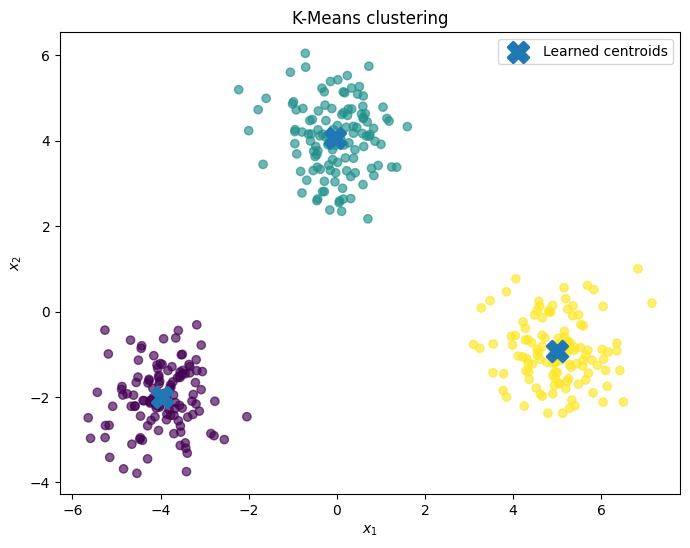

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.65)
plt.scatter(
    M[:, 0],
    M[:, 1],
    marker="X",
    s=220,
    linewidths=2,
    label="Learned centroids",
)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("K-Means clustering")
plt.legend()
plt.show()


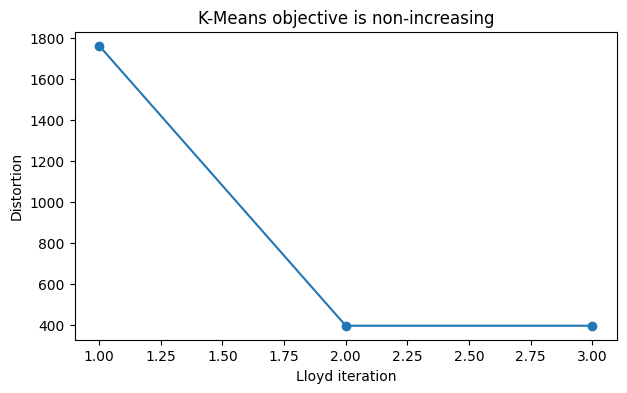

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(history) + 1), history, marker="o")
plt.xlabel("Lloyd iteration")
plt.ylabel("Distortion")
plt.title("K-Means objective is non-increasing")
plt.show()



# 12. Final compression

K-Means begins with one objective:

$$
\boxed{
J(Z,M)
=
\sum_{i,k}
z_{ik}\|x_i-\mu_k\|^2.
}
$$

Holding $M$ fixed gives the exact assignment solution:

$$
\boxed{
c_i=\arg\min_k\|x_i-\mu_k\|^2.
}
$$

Holding $Z$ fixed gives the exact centroid solution:

$$
\boxed{
\mu_k
=
\frac{\sum_i z_{ik}x_i}{\sum_i z_{ik}}.
}
$$

All centroids simultaneously:

$$
\boxed{
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
}
$$

And Lloyd's algorithm is simply repeated composition:

$$
\boxed{
M
\rightarrow
Z
\rightarrow
M
\rightarrow
Z
\rightarrow\cdots
}
$$

with each step guaranteed not to increase $J$.

The implementation mirrors the derivation:

```python
Z = assign(X, M)
M = means(X, Z)
```

That is K-Means in its most compact form:

$$
\boxed{
\text{nearest representative}
\;\longleftrightarrow\;
\text{mean of represented points}.
}
$$
